# Canadian Job Market Analytics — EDA

This notebook explores the `jobs` and `job_skills` tables from the PostgreSQL database and summarizes key patterns for the dashboard.


# 🍁 Canadian Job Market Analytics
## Exploratory Data Analysis (EDA)

**Project:** Canadian Job Market Analytics  
**Notebook:** `01_eda.ipynb`  
**Database:** PostgreSQL — `canadian_jobs_db` (local)  
**Dataset:** 20,462 Canadian data job postings  
**Stack:** Python · PostgreSQL · Pandas · Plotly · Seaborn  

---

| Section | Description |
|---|---|
| 1 | Dataset Overview — shape, dtypes, null counts |
| 2 | Salary Distribution — histogram + boxplot |
| 3 | Top Roles, Cities, Companies — bar charts |
| 4 | Skills Frequency Analysis |
| 5 | Remote vs On-site Breakdown |
| 6 | Salary by Role, City, Seniority |
| 7 | Posting Trends Over Time |
| 8 | Skill Co-occurrence / Correlation |
| 9 | Missing Data Heatmap |
| 10 | Key Insights Summary |



In [3]:
# db_connection.py — local PostgreSQL only
import os
import psycopg2
import pandas as pd

DB_CONFIG = {
    "dbname"  : os.getenv("LOCAL_DB_NAME",     "canadian_jobs_db"),
    "user"    : os.getenv("LOCAL_DB_USER",     "postgres"),
    "password": os.getenv("LOCAL_DB_PASSWORD", ""),
    "host"    : os.getenv("LOCAL_DB_HOST",     "localhost"),
    "port"    : int(os.getenv("LOCAL_DB_PORT", "5432")),
}


def get_connection():
    return psycopg2.connect(**DB_CONFIG)


def run_query(sql: str, params=None) -> pd.DataFrame:
    with get_connection() as conn:
        return pd.read_sql_query(sql, conn, params=params)

In [4]:
from db_connection import run_query

cols = run_query("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_name = 'jobs'
    ORDER BY ordinal_position;
""")
display(cols)

d:\Codes\Canadian Job Market Analytics\notebooks\db_connection.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


,column_name,data_type
0,job_id,integer
1,job_title,text
2,role,text
3,company,text
4,city,text
5,location,text
6,country,text
7,salary_year_avg,numeric
8,salary_hour_avg,numeric
9,salary_rate,text


In [5]:
cols2 = run_query("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_name = 'job_skills'
    ORDER BY ordinal_position;
""")
display(cols2)

d:\Codes\Canadian Job Market Analytics\notebooks\db_connection.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn, params=params)


,column_name,data_type
0,id,integer
1,job_id,integer
2,skill,text


In [26]:
#importing libraries
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from itertools import combinations
from collections import Counter

from db_connection import run_query

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

OUTPUTS = os.path.abspath("../outputs")
os.makedirs(OUTPUTS, exist_ok=True)

print("✅ Imports OK")
print(f"📁 Outputs → {OUTPUTS}")

✅ Imports OK
📁 Outputs → d:\Codes\Canadian Job Market Analytics\outputs


In [27]:
jobs   = run_query("SELECT * FROM jobs;")
skills = run_query("SELECT * FROM job_skills;")

# ── Cast dtypes ──────────────────────────────────────────────
jobs["posted_date"]     = pd.to_datetime(jobs["posted_date"], errors="coerce")
jobs["salary_year_avg"] = pd.to_numeric(jobs["salary_year_avg"], errors="coerce")
jobs["salary_hour_avg"] = pd.to_numeric(jobs["salary_hour_avg"], errors="coerce")
jobs["remote"]          = jobs["remote"].astype(bool)
skills["skill"]         = skills["skill"].str.lower().str.strip()

# ── Seniority from job_title ─────────────────────────────────
def infer_seniority(title: str) -> str:
    t = str(title).lower()
    if any(k in t for k in ["senior","sr.","sr ","lead","principal","staff","manager","head"]):
        return "Senior"
    if any(k in t for k in ["junior","jr.","jr ","entry","associate","intern","graduate","new grad"]):
        return "Junior"
    return "Mid"

jobs["seniority"] = jobs["job_title"].apply(infer_seniority)

print(f"✅ jobs   → {jobs.shape[0]:,} rows × {jobs.shape[1]} cols")
print(f"✅ skills → {len(skills):,} rows | {skills['skill'].nunique():,} unique skills")
print(f"\nSeniority split:\n{jobs['seniority'].value_counts()}")

✅ jobs   → 20,462 rows × 18 cols
✅ skills → 116,180 rows | 5,604 unique skills

Seniority split:
seniority
Mid       12847
Senior     6501
Junior     1114
Name: count, dtype: int64


In [28]:
print("━"*58)
print("  SECTION 1 — DATASET OVERVIEW")
print("━"*58)

sal = jobs["salary_year_avg"].dropna()

overview = {
    "Total postings"       : f"{len(jobs):,}",
    "Columns"              : jobs.shape[1],
    "Date range"           : f"{jobs['posted_date'].min().date()} → {jobs['posted_date'].max().date()}",
    "Unique roles"         : jobs["role"].nunique(),
    "Unique cities"        : jobs["city"].nunique(),
    "Unique companies"     : f"{jobs['company'].nunique():,}",
    "Unique skills"        : f"{skills['skill'].nunique():,}",
    "Remote postings"      : f"{jobs['remote'].sum():,} ({jobs['remote'].mean()*100:.1f}%)",
    "Salary coverage"      : f"{len(sal):,} ({len(sal)/len(jobs)*100:.1f}%)",
    "Salary median"        : f"${sal.median():,.0f}",
    "Salary mean"          : f"${sal.mean():,.0f}",
    "Sources"              : jobs["source"].value_counts().to_dict(),
}

print()
for k, v in overview.items():
    print(f"  {k:<28}: {v}")

print("\n── Null Counts ──")
null_df = pd.DataFrame({
    "null_count": jobs.isnull().sum(),
    "null_%"    : (jobs.isnull().sum() / len(jobs) * 100).round(1)
}).query("null_count > 0").sort_values("null_%", ascending=False)
display(null_df)

print("\n── Data Types ──")
display(jobs.dtypes.rename("dtype").to_frame())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 1 — DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Total postings              : 20,462
  Columns                     : 18
  Date range                  : 2023-01-01 → 2023-12-31
  Unique roles                : 8
  Unique cities               : 665
  Unique companies            : 5,092
  Unique skills               : 5,604
  Remote postings             : 2,570 (12.6%)
  Salary coverage             : 949 (4.6%)
  Salary median               : $139,632
  Salary mean                 : $151,418
  Sources                     : {'lukebarousse': 14104, 'techsalerator': 5454, 'asaniczka': 464, 'elahehgolrokh': 440}

── Null Counts ──


,null_count,null_%
salary_hour_avg,20417,99.80
salary_rate,19516,95.40
salary_year_avg,19513,95.40
posted_date,6358,31.10
location,162,0.80



── Data Types ──


,dtype
job_id,int64
job_title,str
role,str
company,str
city,str
location,str
country,str
salary_year_avg,float64
salary_hour_avg,float64
salary_rate,str


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 9 — MISSING DATA HEATMAP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


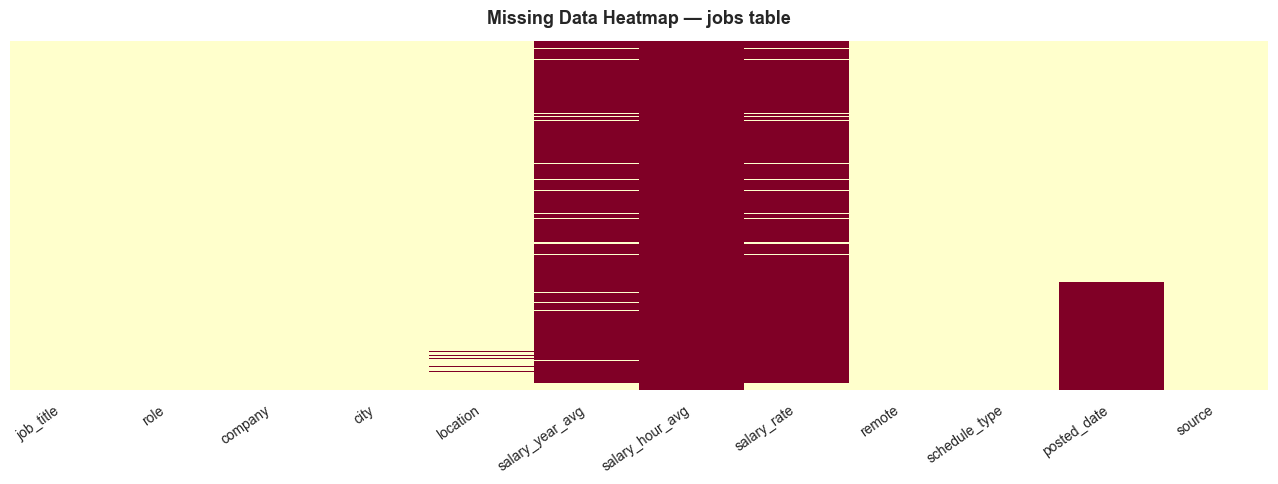

✅ Saved: eda_01_missing_heatmap.png


In [29]:
print("━"*58)
print("  SECTION 9 — MISSING DATA HEATMAP")
print("━"*58)

plot_cols = ["job_title","role","company","city","location",
             "salary_year_avg","salary_hour_avg","salary_rate",
             "remote","schedule_type","posted_date","source"]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    jobs[plot_cols].isnull(),
    cbar=False, yticklabels=False,
    cmap="YlOrRd", ax=ax
)
ax.set_title("Missing Data Heatmap — jobs table",
             fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=35, ha="right", fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}/eda_01_missing_heatmap.png", dpi=150)
plt.show()
print("✅ Saved: eda_01_missing_heatmap.png")

In [30]:
print("━"*58)
print("  SECTION 2 — SALARY DISTRIBUTION")
print("━"*58)

sal = jobs["salary_year_avg"].dropna()
print(f"Salary rows: {len(sal):,} / {len(jobs):,} ({len(sal)/len(jobs)*100:.1f}%)")
print(sal.describe().apply("${:,.0f}".format))

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        f"Annual Salary Distribution (n={len(sal):,})",
        "Salary — Remote vs On-site"
    )
)

fig.add_trace(
    go.Histogram(x=sal, nbinsx=50, name="All Jobs",
                 marker_color="#0068C9", opacity=0.85),
    row=1, col=1
)

for is_remote, label, color in [(False, "On-site", "#FF7043"), (True, "Remote", "#29B09D")]:
    subset = jobs[jobs["remote"] == is_remote]["salary_year_avg"].dropna()
    fig.add_trace(
        go.Box(y=subset, name=label, marker_color=color, boxmean=True),
        row=1, col=2
    )

fig.update_layout(
    title_text="💰 Salary Distribution — Canadian Data Jobs",
    height=430, template="plotly_white"
)
fig.update_xaxes(title_text="Annual Salary (CAD)", row=1, col=1)
fig.update_yaxes(title_text="Postings",            row=1, col=1)
fig.update_yaxes(title_text="Annual Salary (CAD)", tickformat="$,.0f", row=1, col=2)
fig.write_html(f"{OUTPUTS}/eda_02_salary_distribution.html")
fig.show()
print("✅ Saved: eda_02_salary_distribution.html")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 2 — SALARY DISTRIBUTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Salary rows: 949 / 20,462 (4.6%)
count        $949
mean     $151,418
std       $73,417
min       $26,986
25%       $91,200
50%      $139,632
75%      $198,041
max      $382,510
Name: salary_year_avg, dtype: str


✅ Saved: eda_02_salary_distribution.html


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 3 — TOP ROLES / CITIES / COMPANIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


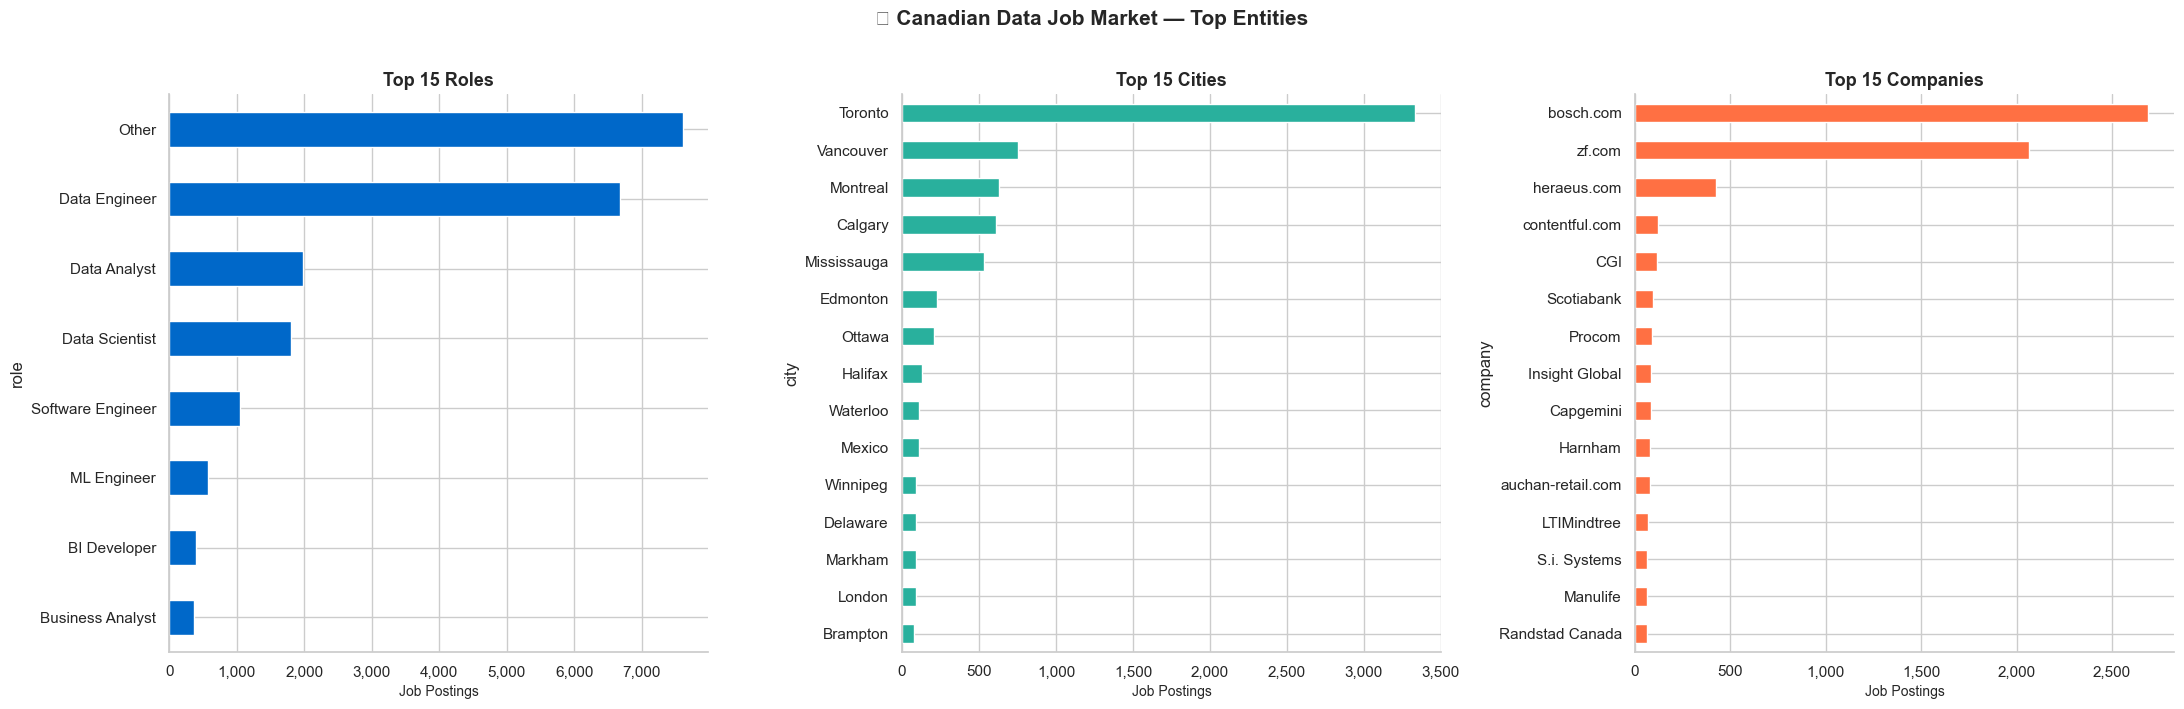

✅ Saved: eda_03_top_roles_cities_companies.png


In [31]:
print("━"*58)
print("  SECTION 3 — TOP ROLES / CITIES / COMPANIES")
print("━"*58)

TOP_N = 15

top_roles     = jobs["role"].value_counts().head(TOP_N)
top_cities    = jobs[~jobs["city"].isin(["Unspecified","Remote"])]["city"].value_counts().head(TOP_N)
top_companies = jobs["company"].value_counts().head(TOP_N)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
datasets = [
    (top_roles,     "Top 15 Roles",     "#0068C9"),
    (top_cities,    "Top 15 Cities",    "#29B09D"),
    (top_companies, "Top 15 Companies", "#FF7043"),
]
for ax, (data, title, color) in zip(axes, datasets):
    data.sort_values().plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Job Postings", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.suptitle("🍁 Canadian Data Job Market — Top Entities",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}/eda_03_top_roles_cities_companies.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_03_top_roles_cities_companies.png")

In [32]:
print("━"*58)
print("  SECTION 4 — SKILLS FREQUENCY ANALYSIS")
print("━"*58)

skill_counts = skills["skill"].value_counts()
top25        = skill_counts.head(25)

print("── Top 10 Skills ──")
print(top25.head(10).apply(lambda x: f"{x:,}").rename("postings").to_frame())

fig = px.bar(
    x=top25.values,
    y=top25.index,
    orientation="h",
    title="🛠️ Top 25 In-Demand Skills — Canadian Data Jobs",
    labels={"x": "Job Postings", "y": "Skill"},
    color=top25.values,
    color_continuous_scale="Blues",
    template="plotly_white",
    text=top25.values,
)
fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.update_layout(
    height=680,
    yaxis=dict(autorange="reversed"),
    coloraxis_showscale=False,
    margin=dict(l=10, r=80, t=60, b=40)
)
fig.write_html(f"{OUTPUTS}/eda_04_skills_frequency.html")
fig.show()
print("✅ Saved: eda_04_skills_frequency.html")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 4 — SKILLS FREQUENCY ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
── Top 10 Skills ──
         postings
skill            
python      9,081
sql         8,973
aws         4,247
azure       4,026
spark       3,514
sap         3,077
java        2,665
power bi    2,402
tableau     2,394
excel       2,084


✅ Saved: eda_04_skills_frequency.html


In [33]:
print("━"*58)
print("  SECTION 5 — REMOTE vs ON-SITE BREAKDOWN")
print("━"*58)

remote_counts   = jobs["remote"].map({True: "Remote", False: "On-site"}).value_counts()
schedule_counts = jobs["schedule_type"].value_counts().head(8)

print(remote_counts.apply(lambda x: f"{x:,} ({x/len(jobs)*100:.1f}%)"))

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "domain"}, {"type": "xy"}]],
    subplot_titles=("Remote vs On-site", "Schedule Type Breakdown")
)

fig.add_trace(
    go.Pie(
        labels=remote_counts.index, values=remote_counts.values,
        hole=0.45, marker_colors=["#FF7043", "#0068C9"],
        textinfo="percent+label", name=""
    ), row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=schedule_counts.values, y=schedule_counts.index,
        orientation="h", marker_color="#29B09D", name=""
    ), row=1, col=2
)

fig.update_layout(
    title_text="🏠 Work Arrangement — Canadian Data Jobs",
    height=420, template="plotly_white", showlegend=False
)
fig.write_html(f"{OUTPUTS}/eda_05_remote_breakdown.html")
fig.show()
print("✅ Saved: eda_05_remote_breakdown.html")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 5 — REMOTE vs ON-SITE BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
remote
On-site    17,892 (87.4%)
Remote      2,570 (12.6%)
Name: count, dtype: str


✅ Saved: eda_05_remote_breakdown.html


In [34]:
print("━"*58)
print("  SECTION 6 — SALARY BY ROLE, CITY, SENIORITY")
print("━"*58)

def salary_box_chart(col: str, top_n: int, title: str, filename: str):
    top_vals = jobs[col].value_counts().head(top_n).index
    subset   = jobs[jobs[col].isin(top_vals) & jobs["salary_year_avg"].notna()].copy()
    order    = (subset.groupby(col)["salary_year_avg"]
                      .median().sort_values().index.tolist())
    fig = px.box(
        subset, x=col, y="salary_year_avg",
        category_orders={col: order},
        title=title,
        labels={"salary_year_avg": "Annual Salary (CAD)", col: ""},
        template="plotly_white",
        color=col,
        points=False,
    )
    fig.update_layout(showlegend=False, height=500, yaxis_tickformat="$,.0f")
    fig.write_html(f"{OUTPUTS}/{filename}")
    fig.show()
    print(f"✅ Saved: {filename}")

salary_box_chart("role",      12, "💼 Salary by Role (Top 12)",   "eda_06a_salary_by_role.html")
salary_box_chart("city",      12, "🏙️ Salary by City (Top 12)",   "eda_06b_salary_by_city.html")
salary_box_chart("seniority",  3, "📊 Salary by Seniority Level", "eda_06c_salary_by_seniority.html")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 6 — SALARY BY ROLE, CITY, SENIORITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


✅ Saved: eda_06a_salary_by_role.html


✅ Saved: eda_06b_salary_by_city.html


✅ Saved: eda_06c_salary_by_seniority.html


In [35]:
print("━"*58)
print("  SECTION 7 — POSTING TRENDS OVER TIME")
print("━"*58)

jobs_dated = jobs.dropna(subset=["posted_date"]).copy()
jobs_dated["month_start"] = jobs_dated["posted_date"].dt.to_period("M").dt.to_timestamp()

# ── Monthly volume ────────────────────────────────────────────
monthly = (jobs_dated
    .groupby("month_start").size()
    .reset_index(name="postings")
)

fig1 = px.line(
    monthly, x="month_start", y="postings",
    title="📅 Monthly Job Posting Volume — Canadian Data Jobs",
    labels={"month_start": "Month", "postings": "Postings"},
    markers=True, template="plotly_white",
    color_discrete_sequence=["#0068C9"],
)
fig1.update_layout(height=400)
fig1.write_html(f"{OUTPUTS}/eda_07a_posting_trends.html")
fig1.show()

# ── Top 6 roles over time (stacked area) ─────────────────────
top6 = jobs["role"].value_counts().head(6).index.tolist()
monthly_role = (jobs_dated[jobs_dated["role"].isin(top6)]
    .groupby(["month_start", "role"]).size()
    .reset_index(name="postings")
)

fig2 = px.area(
    monthly_role, x="month_start", y="postings", color="role",
    title="📈 Top 6 Roles — Posting Trend Over Time",
    labels={"month_start": "Month", "postings": "Postings", "role": "Role"},
    template="plotly_white",
)
fig2.update_layout(height=430)
fig2.write_html(f"{OUTPUTS}/eda_07b_posting_trends_by_role.html")
fig2.show()

print("✅ Saved: eda_07a_posting_trends.html")
print("✅ Saved: eda_07b_posting_trends_by_role.html")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 7 — POSTING TRENDS OVER TIME
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


✅ Saved: eda_07a_posting_trends.html
✅ Saved: eda_07b_posting_trends_by_role.html


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 8 — SKILL CO-OCCURRENCE HEATMAP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


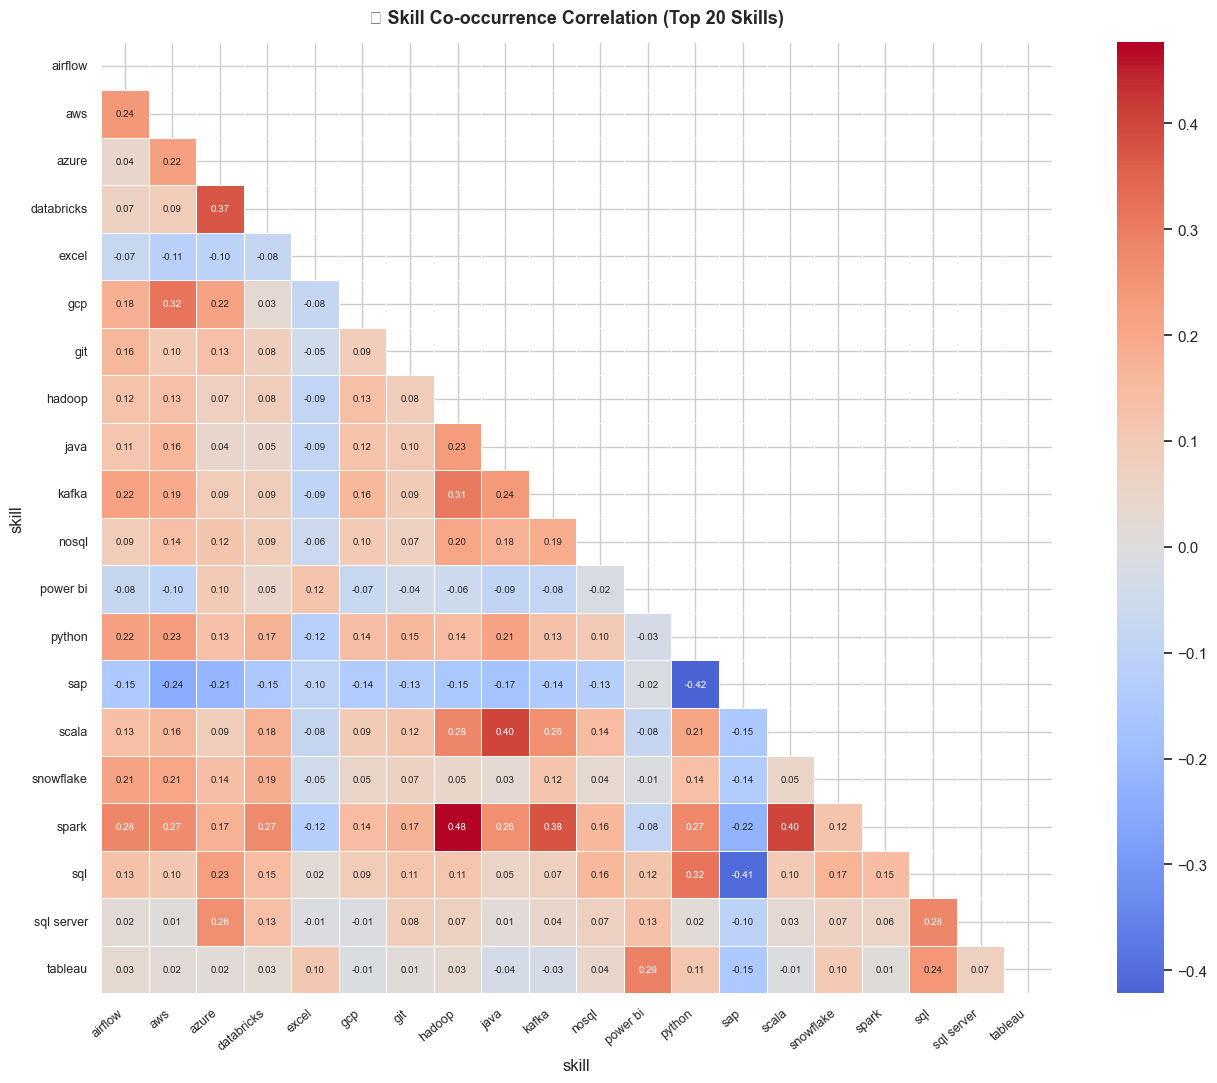

✅ Saved: eda_08_skill_cooccurrence.png

── Top 15 Skill Pairs (co-occurrence count) ──


,skill_pair,count
0,python + sql,6115
1,aws + python,3106
2,azure + sql,2933
3,python + spark,2814
4,aws + sql,2617
5,azure + python,2611
6,spark + sql,2361
7,java + python,2068
8,sql + tableau,1979
9,aws + azure,1693


In [36]:
print("━"*58)
print("  SECTION 8 — SKILL CO-OCCURRENCE HEATMAP")
print("━"*58)

TOP_SKILLS = 20
top_skill_list = skills["skill"].value_counts().head(TOP_SKILLS).index.tolist()

# ── Binary pivot: job_id × skill ─────────────────────────────
skill_pivot = (
    skills[skills["skill"].isin(top_skill_list)]
    .drop_duplicates(["job_id", "skill"])
    .assign(present=1)
    .pivot(index="job_id", columns="skill", values="present")
    .fillna(0)
)

corr_matrix = skill_pivot.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.4,
    linecolor="white", annot_kws={"size": 7},
    ax=ax, square=True,
)
ax.set_title(f"🔗 Skill Co-occurrence Correlation (Top {TOP_SKILLS} Skills)",
             fontsize=13, fontweight="bold", pad=14)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}/eda_08_skill_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_08_skill_cooccurrence.png")

# ── Top 15 skill pairs ────────────────────────────────────────
print("\n── Top 15 Skill Pairs (co-occurrence count) ──")
pair_counts = Counter()
for _, group in skills[skills["skill"].isin(top_skill_list)].groupby("job_id")["skill"]:
    for pair in combinations(sorted(group), 2):
        pair_counts[pair] += 1

pair_df = pd.DataFrame(
    pair_counts.most_common(15),
    columns=["skill_pair", "count"]
).assign(skill_pair=lambda d: d["skill_pair"].apply(lambda x: f"{x[0]}  +  {x[1]}"))
display(pair_df)

In [37]:
print("━"*58)
print("  SECTION 10 — KEY INSIGHTS SUMMARY")
print("━"*58)

sal = jobs["salary_year_avg"].dropna()

def med_sal(mask):
    s = jobs[mask]["salary_year_avg"].dropna()
    return f"${s.median():,.0f}" if len(s) else "n/a"

summary = {
    "Total postings"          : f"{len(jobs):,}",
    "Unique skills"           : f"{skills['skill'].nunique():,}",
    "Date range"              : f"{jobs['posted_date'].min().date()} → {jobs['posted_date'].max().date()}",
    "Salary coverage"         : f"{len(sal):,} ({len(sal)/len(jobs)*100:.1f}%)",
    "Median salary"           : f"${sal.median():,.0f}",
    "Mean salary"             : f"${sal.mean():,.0f}",
    "Salary IQR"              : f"${sal.quantile(0.25):,.0f} – ${sal.quantile(0.75):,.0f}",
    "Top role"                : jobs["role"].value_counts().idxmax(),
    "Top city"                : jobs[~jobs["city"].isin(["Unspecified","Remote"])]["city"].value_counts().idxmax(),
    "Top company"             : jobs["company"].value_counts().idxmax(),
    "Top skill"               : skills["skill"].value_counts().idxmax(),
    "Remote share"            : f"{jobs['remote'].mean()*100:.1f}%",
    "Senior median salary"    : med_sal(jobs["seniority"] == "Senior"),
    "Mid median salary"       : med_sal(jobs["seniority"] == "Mid"),
    "Junior median salary"    : med_sal(jobs["seniority"] == "Junior"),
    "Most common schedule"    : jobs["schedule_type"].value_counts().idxmax(),
    "Most common source"      : jobs["source"].value_counts().idxmax(),
}

print()
for k, v in summary.items():
    print(f"  {k:<30}: {v}")

pd.DataFrame(list(summary.items()), columns=["Metric", "Value"]).to_csv(
    f"{OUTPUTS}/eda_10_key_insights.csv", index=False
)
print(f"\n✅ Saved: eda_10_key_insights.csv")
print("\n🎉 EDA COMPLETE — All outputs saved to /outputs/")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SECTION 10 — KEY INSIGHTS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Total postings                : 20,462
  Unique skills                 : 5,604
  Date range                    : 2023-01-01 → 2023-12-31
  Salary coverage               : 949 (4.6%)
  Median salary                 : $139,632
  Mean salary                   : $151,418
  Salary IQR                    : $91,200 – $198,041
  Top role                      : Other
  Top city                      : Toronto
  Top company                   : bosch.com
  Top skill                     : python
  Remote share                  : 12.6%
  Senior median salary          : $125,000
  Mid median salary             : $145,000
  Junior median salary          : $70,000
  Most common schedule          : Full-time
  Most common source            : lukebarousse

✅ Saved: eda_10_key_insights.csv

🎉 EDA COMPLETE — All outputs saved to /outputs/
